In [1]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# maximum number of rows to display
pd.options.display.max_rows = 50

In [3]:
connection = sqlite3.connect(r'C:\Users\hp\Downloads\bike_store.db')

In [4]:
stocks = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\DS Notes\SQL\SQL Datasets\store_data\stocks.csv')
stocks

,store_id,product_id,quantity
0,1,1,27
1,1,2,5
2,1,3,6
3,1,4,23
4,1,5,22
...,...,...,...
934,3,309,30
935,3,310,8
936,3,311,23
937,3,312,18


In [5]:
stores = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\DS Notes\SQL\SQL Datasets\store_data\stores.csv')
stores

,store_id,store_name,phone,email,street,city,state,zip_code
0,1,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060
1,2,Baldwin Bikes,(516) 379-8888,baldwin@bikes.shop,4200 Chestnut Lane,Baldwin,NY,11432
2,3,Rowlett Bikes,(972) 530-5555,rowlett@bikes.shop,8000 Fairway Avenue,Rowlett,TX,75088


In [6]:
staffs = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\DS Notes\SQL\SQL Datasets\store_data\staffs.csv')
staffs

,staff_id,first_name,last_name,email,phone,active,store_id,manager_id
0,1,Fabiola,Jackson,fabiola.jackson@bikes.shop,(831) 555-5554,1,1,NaN
1,2,Mireya,Copeland,mireya.copeland@bikes.shop,(831) 555-5555,1,1,1.0
2,3,Genna,Serrano,genna.serrano@bikes.shop,(831) 555-5556,1,1,2.0
3,4,Virgie,Wiggins,virgie.wiggins@bikes.shop,(831) 555-5557,1,1,2.0
4,5,Jannette,David,jannette.david@bikes.shop,(516) 379-4444,1,2,1.0
5,6,Marcelene,Boyer,marcelene.boyer@bikes.shop,(516) 379-4445,1,2,5.0
6,7,Venita,Daniel,venita.daniel@bikes.shop,(516) 379-4446,1,2,5.0
7,8,Kali,Vargas,kali.vargas@bikes.shop,(972) 530-5555,1,3,1.0
8,9,Layla,Terrell,layla.terrell@bikes.shop,(972) 530-5556,1,3,7.0
9,10,Bernardine,Houston,bernardine.houston@bikes.shop,(972) 530-5557,1,3,7.0


In [7]:
products = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\DS Notes\SQL\SQL Datasets\store_data\products.csv')
products

,product_id,product_name,brand_id,category_id,model_year,list_price
0,1,Trek 820 - 2016,9,6,2016,379.99
1,2,Ritchey Timberwolf Frameset - 2016,5,6,2016,749.99
2,3,Surly Wednesday Frameset - 2016,8,6,2016,999.99
3,4,Trek Fuel EX 8 29 - 2016,9,6,2016,2899.99
4,5,Heller Shagamaw Frame - 2016,3,6,2016,1320.99
...,...,...,...,...,...,...
316,317,Trek Checkpoint ALR 5 - 2019,9,7,2019,1999.99
317,318,Trek Checkpoint ALR 5 Women's - 2019,9,7,2019,1999.99
318,319,Trek Checkpoint SL 5 Women's - 2019,9,7,2019,2799.99
319,320,Trek Checkpoint SL 6 - 2019,9,7,2019,3799.99


In [8]:
orders = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\DS Notes\SQL\SQL Datasets\store_data\orders.csv')
orders

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id
0,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2
1,2,1212,4,2016-01-01,2016-01-04,2016-01-03,2,6
2,3,523,4,2016-01-02,2016-01-05,2016-01-03,2,7
3,4,175,4,2016-01-03,2016-01-04,2016-01-05,1,3
4,5,1324,4,2016-01-03,2016-01-06,2016-01-06,2,6
...,...,...,...,...,...,...,...,...
1610,1611,6,3,2018-09-06,2018-09-06,NaN,2,7
1611,1612,3,3,2018-10-21,2018-10-21,NaN,1,3
1612,1613,1,3,2018-11-18,2018-11-18,NaN,2,6
1613,1614,135,3,2018-11-28,2018-11-28,NaN,3,8


In [9]:
orders_items = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\DS Notes\SQL\SQL Datasets\store_data\order_items.csv')
orders_items

,order_id,item_id,product_id,quantity,list_price,discount
0,1,1,20,1,599.99,0.20
1,1,2,8,2,1799.99,0.07
2,1,3,10,2,1549.00,0.05
3,1,4,16,2,599.99,0.05
4,1,5,4,1,2899.99,0.20
...,...,...,...,...,...,...
4717,1614,2,159,2,2299.99,0.07
4718,1614,3,213,2,269.99,0.20
4719,1615,1,197,2,2299.99,0.20
4720,1615,2,214,1,899.99,0.07


In [10]:
customers = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\DS Notes\SQL\SQL Datasets\store_data\customers.csv')
customers

,customer_id,first_name,last_name,phone,email,street,city,state,zip_code
0,1,Debra,Burks,NaN,debra.burks@yahoo.com,9273 Thorne Ave.,Orchard Park,NY,14127
1,2,Kasha,Todd,NaN,kasha.todd@yahoo.com,910 Vine Street,Campbell,CA,95008
2,3,Tameka,Fisher,NaN,tameka.fisher@aol.com,769C Honey Creek St.,Redondo Beach,CA,90278
3,4,Daryl,Spence,NaN,daryl.spence@aol.com,988 Pearl Lane,Uniondale,NY,11553
4,5,Charolette,Rice,(916) 381-6003,charolette.rice@msn.com,107 River Dr.,Sacramento,CA,95820
...,...,...,...,...,...,...,...,...,...
1440,1441,Jamaal,Morrison,NaN,jamaal.morrison@msn.com,796 SE. Nut Swamp St.,Staten Island,NY,10301
1441,1442,Cassie,Cline,NaN,cassie.cline@gmail.com,947 Lafayette Drive,Brooklyn,NY,11201
1442,1443,Lezlie,Lamb,NaN,lezlie.lamb@gmail.com,401 Brandywine Street,Central Islip,NY,11722
1443,1444,Ivette,Estes,NaN,ivette.estes@gmail.com,88 N. Canterbury Ave.,Canandaigua,NY,14424


In [11]:
categories = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\DS Notes\SQL\SQL Datasets\store_data\categories.csv')
categories

,category_id,category_name
0,1,Children Bicycles
1,2,Comfort Bicycles
2,3,Cruisers Bicycles
3,4,Cyclocross Bicycles
4,5,Electric Bikes
5,6,Mountain Bikes
6,7,Road Bikes


In [12]:
brands = pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\DS Notes\SQL\SQL Datasets\store_data\brands.csv')
brands

,brand_id,brand_name
0,1,Electra
1,2,Haro
2,3,Heller
3,4,Pure Cycles
4,5,Ritchey
5,6,Strider
6,7,Sun Bicycles
7,8,Surly
8,9,Trek


In [13]:
brands.to_sql("brands", connection, if_exists = "replace", index = False)
categories.to_sql("categories", connection, if_exists = "replace", index = False)
customers.to_sql("customers", connection, if_exists = "replace", index = False)
orders_items.to_sql("orders_items", connection, if_exists = "replace", index = False)
orders.to_sql("orders", connection, if_exists = "replace", index = False)
products.to_sql("products", connection, if_exists = "replace", index = False)
staffs.to_sql("staffs", connection, if_exists = "replace", index = False)
stores.to_sql("stores", connection, if_exists = "replace", index = False)
stocks.to_sql("stocks", connection, if_exists = "replace", index = False)

Leveraged advanced SQL queries to extract meaningful sales information from each product category, enhancing business insights and decision-making for a BIKE SALES STORE.

- Established a detailed employee hierarchy using recursive SQL queries to better understand organizational structure and reporting lines.
- Calculated the 30-day moving average of orders to identify trends and monitor performance over time.
- Conducted customer segmentation based on order count, total spent, and recency to tailor marketing strategies and improve customer relationship management.
- Performed seasonality and ranking analysis to identify peak sales periods and top-performing products.
- Executed market basket analysis to uncover frequently co-purchased products, aiding in cross-selling and upselling strategies.
- Analyzed average time intervals between consecutive purchases to understand customer buying patterns and optimize re-engagement tactics.

In [14]:
# extract the trekking products of 2019 which are above the avg price.
pd.read_sql("""

SELECT p.product_name as name, list_price
FROM products as p
Where p.brand_id = 9 AND model_year = 2019 AND list_price > (SELECT avg(list_price) from products where model_year = 2019)
;

""", connection)

,name,list_price
0,Trek Checkpoint SL 5 Women's - 2019,2799.99
1,Trek Checkpoint SL 6 - 2019,3799.99
2,Trek Checkpoint ALR Frameset - 2019,3199.99


In [15]:
pd.read_sql("""

SELECT avg(list_price) from products where model_year = 2019;

""", connection)

,avg(list_price)
0,2583.323333


In [16]:
# extract only those order id and customer id where we have trekking producs discounted with atleast 20% and there can be 
# duplicate id for customers with more than one order.

pd.read_sql("""

SELECT Distinct order_id, customer_id from orders
where order_id in (
    select Distinct order_id from orders_items o 
    join products p on o.product_id = p.product_id
    where discount >= 0.2 AND brand_id = 9
)
GROUP BY order_id;

""", connection)

,order_id,customer_id
0,1,259
1,16,552
2,19,696
3,28,252
4,29,437
...,...,...
293,1601,43
294,1602,55
295,1605,123
296,1610,15


In [17]:
pd.read_sql("""

    SELECT 
        DISTINCT
        order_id,
        customer_id
    FROM 
        orders
    WHERE 
        EXISTS (
                SELECT
                    1
                FROM
                    orders_items
                WHERE
                    discount >= .20
                AND
                    orders_items.order_id = orders.order_id);

""", connection)

,order_id,customer_id
0,1,259
1,11,1326
2,15,450
3,16,552
4,17,1175
...,...,...
855,1610,15
856,1611,6
857,1612,3
858,1614,135


In [18]:
# Calculated the 30-day moving average of orders to identify trends and monitor performance over time.
average = pd.read_sql("""

WITH daily_orders AS (
    SELECT
        order_date,
        store_id,
        COUNT(*) AS orders
    FROM
        orders
    GROUP BY
        1,2
)

SELECT
    order_date,
    store_id,
    AVG(orders) OVER(PARTITION BY store_id 
                     ORDER BY order_date ASC
                     ROWS BETWEEN 14 PRECEDING AND 15 FOLLOWING) AS moving_avg_30d
FROM
    daily_orders
order by order_date;

""", connection)

average

,order_date,store_id,moving_avg_30d
0,2016-01-01,1,1.250000
1,2016-01-01,2,1.750000
2,2016-01-02,2,1.764706
3,2016-01-03,1,1.235294
4,2016-01-03,2,1.777778
...,...,...,...
1049,2018-09-06,2,1.750000
1050,2018-10-21,1,2.266667
1051,2018-11-18,2,1.733333
1052,2018-11-28,3,1.187500


[]

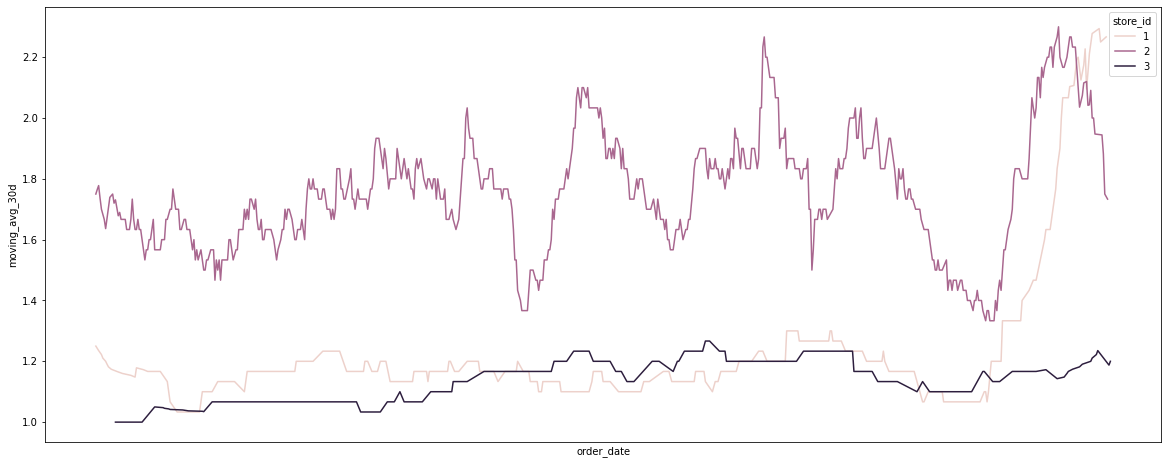

In [19]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(data=average, x='order_date', y='moving_avg_30d', hue='store_id', ax=ax)
ax.set_xticks([])
# ax.set_yticks([])

In [20]:
# Conducted customer segmentation based on order count, total spent, and recency to tailor marketing strategies and 
# improve customer relationship management.

summary = pd.read_sql("""

SELECT 
    o.customer_id, COUNT(DISTINCT oi.order_id) AS order_count, 
    SUM(oi.list_price * oi.quantity *(1-oi.discount)) AS total_spent,
    julianday('2018-12-28') - julianday(MAX(order_date)) AS days_since_last_purchase,
    CASE
    WHEN julianday('2018-12-28') - julianday(MAX(order_date)) < 270 THEN '3months_dorment'
    WHEN julianday('2018-12-28') - julianday(MAX(order_date)) BETWEEN 271 AND 540 THEN '3 to 6 months_dorment' 
    WHEN julianday('2018-12-28') - julianday(MAX(order_date)) BETWEEN 541 AND 810 THEN '6 to 12 months_dorment'
    ELSE 'more then 12 months_dorment'
    END AS dorment_bucket
FROM orders o 
join orders_items oi 
on o.order_id = oi.order_id
group by 1
order by 2 desc;

""", connection)
summary

,customer_id,order_count,total_spent,days_since_last_purchase,dorment_bucket
0,116,3,12793.6337,257.0,3months_dorment
1,77,3,8522.9542,252.0,3months_dorment
2,68,3,10802.6294,263.0,3months_dorment
3,66,3,23026.2923,261.0,3months_dorment
4,64,3,8778.1311,268.0,3months_dorment
...,...,...,...,...,...
1440,100,1,5399.9820,306.0,3 to 6 months_dorment
1441,99,1,5431.8955,992.0,more then 12 months_dorment
1442,98,1,2546.4665,979.0,more then 12 months_dorment
1443,96,1,7681.1240,748.0,6 to 12 months_dorment


(array([0, 1, 2, 3]),
 [Text(0, 0, '3months_dorment'),
  Text(1, 0, '6 to 12 months_dorment'),
  Text(2, 0, 'more then 12 months_dorment'),
  Text(3, 0, '3 to 6 months_dorment')])

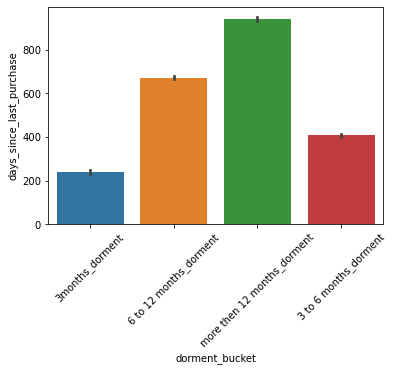

In [21]:
sns.barplot(data = summary, x = 'dorment_bucket', y = 'days_since_last_purchase')
plt.xticks(rotation = 45)

In [22]:
# extract the customer segmentation based on purchase frequency (if total order > 1 then repeat buyer otherwise one time 
# buyer), perchase recency (if days since last purchase less then 90 then recent buyer otherwise not recent) and buying 
# power (porportion of total spent >=70% then big spender, <= 30% low spender, otherwise average spender)

summary1 = pd.read_sql("""
WITH Common_table as
(SELECT 
    o.customer_id,
    COUNT(DISTINCT oi.order_id) as order_count, 
    julianday('2018-12-28') - julianday(MAX(o.order_date)) AS days_since_last_purchase,
    SUM(oi.list_price * oi.quantity *(1-oi.discount)) AS total_spent
FROM orders o 
join orders_items oi 
on o.order_id = oi.order_id
GROUP BY 1)
SELECT customer_id,
    CASE WHEN order_count > 1 THEN 'Repeat buyer'
    ELSE 'one time buyer' END AS purchase_freq,
    CASE WHEN days_since_last_purchase < 90 THEN 'recent buyer'
    ELSE 'non recent' END AS 'perchase recency',
    CASE WHEN total_spent/(SELECT MAX(total_spent) FROM Common_table)>=0.70 THEN 'big spender'
    WHEN total_spent/(SELECT MAX(total_spent) FROM Common_table)<=0.30 THEN 'low spender'
    ELSE 'average spender' END AS 'buying power'
FROM Common_table;

""", connection)
summary1

,customer_id,purchase_freq,perchase recency,buying power
0,1,Repeat buyer,recent buyer,big spender
1,2,Repeat buyer,non recent,average spender
2,3,Repeat buyer,recent buyer,average spender
3,4,Repeat buyer,non recent,average spender
4,5,Repeat buyer,non recent,average spender
...,...,...,...,...
1440,1441,one time buyer,non recent,low spender
1441,1442,one time buyer,non recent,low spender
1442,1443,one time buyer,non recent,low spender
1443,1444,one time buyer,non recent,low spender


Text(0.5, 1.0, 'Buying Power')

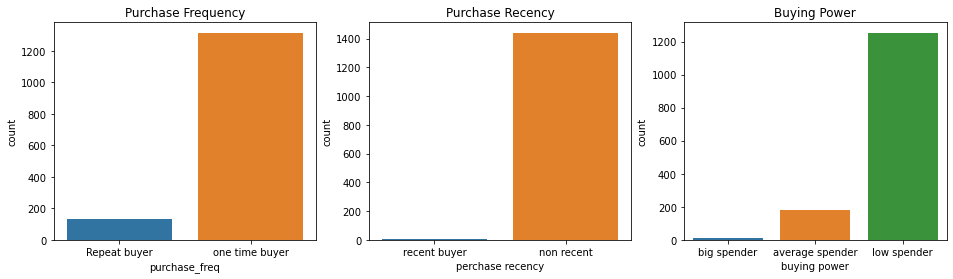

In [23]:
fig, ax = plt.subplots(ncols=3, figsize=(16, 4))
sns.countplot(data = summary1, x = 'purchase_freq', ax = ax[0])
sns.countplot(data = summary1, x = 'perchase recency', ax = ax[1])
sns.countplot(data = summary1, x = 'buying power', ax = ax[2])

ax[0].set_title('Purchase Frequency')
ax[1].set_title('Purchase Recency')
ax[2].set_title('Buying Power')

In [24]:
# inner query 1 - join to have product_id with category name
# inner query 2 - extract year and month from order date along with product id, total unit sold from order and orders_items tables
# outer query - to pull the month, category name, average of total unit sold by joining inner query 1 and 2.

seasonality1 = pd.read_sql("""

With table1 as(
SELECT *
FROM products as p
JOIN categories as c
ON p.category_id  = c.category_id
),
table2 as(
SELECT oi.product_id,
strftime('%m', o.order_date) as month,
strftime('%Y', o.order_date) as year,
SUM(oi.quantity) as total_units
FROM orders as o
        JOIN 
    orders_items as oi 
        ON o.order_id = oi.order_id
GROUP BY 1,2,3
)

SELECT t1.category_name, t2.month, avg(t2.total_units) as avg_units
FROM table1 as t1
JOIN table2 as t2
ON t1.product_id = t2.product_id
GROUP BY 1,2;

""", connection)
seasonality1

,category_name,month,avg_units
0,Children Bicycles,01,2.973684
1,Children Bicycles,02,3.150000
2,Children Bicycles,03,2.920000
3,Children Bicycles,04,3.000000
4,Children Bicycles,05,3.050000
...,...,...,...
79,Road Bikes,08,2.666667
80,Road Bikes,09,2.818182
81,Road Bikes,10,2.300000
82,Road Bikes,11,2.307692


<AxesSubplot:xlabel='month', ylabel='avg_units'>

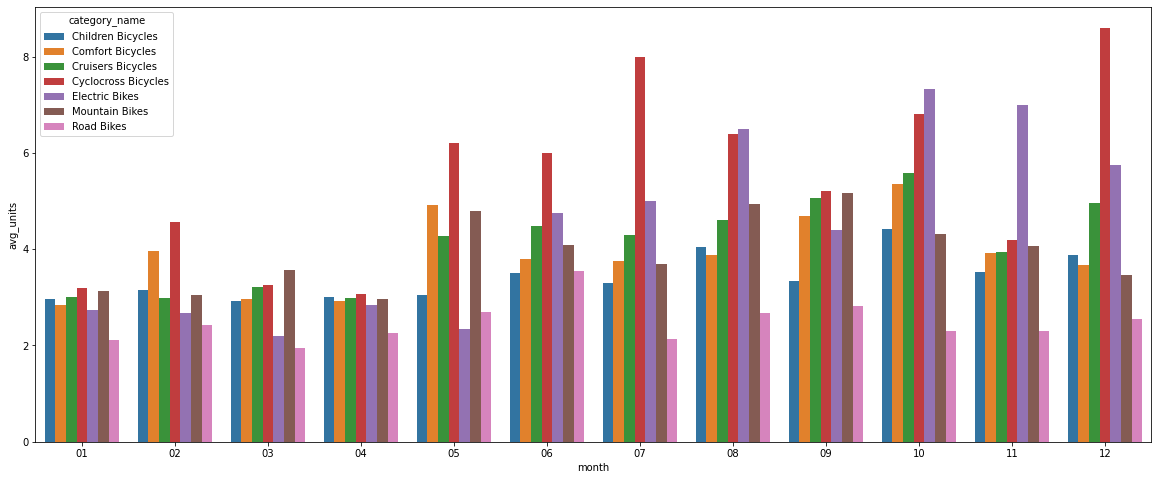

In [25]:
fig, ax = plt.subplots(figsize=(20,8))
sns.barplot(data = seasonality1, x = 'month', y = 'avg_units', hue = 'category_name', ax=ax)

In [26]:
# Performed seasonality and ranking analysis to identify peak sales periods and top-performing products.

seasonality = pd.read_sql("""

SELECT 
    product_id, 
    strftime('%Y-%m', order_date) as months, 
    SUM(oi.list_price * oi.quantity *(1-oi.discount)) AS Sales
FROM 
    orders as o
        JOIN 
    orders_items as oi 
        ON o.order_id = oi.order_id
GROUP BY 2
ORDER BY 2;
""", connection)
seasonality

,product_id,months,Sales
0,4,2016-01,215146.4241
1,13,2016-02,156112.3228
2,7,2016-03,180600.3285
3,8,2016-04,167144.0512
4,6,2016-05,205270.0091
5,7,2016-06,210562.1245
6,7,2016-07,199556.8089
7,14,2016-08,225657.3767
8,5,2016-09,273091.6097
9,11,2016-10,212078.0805


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

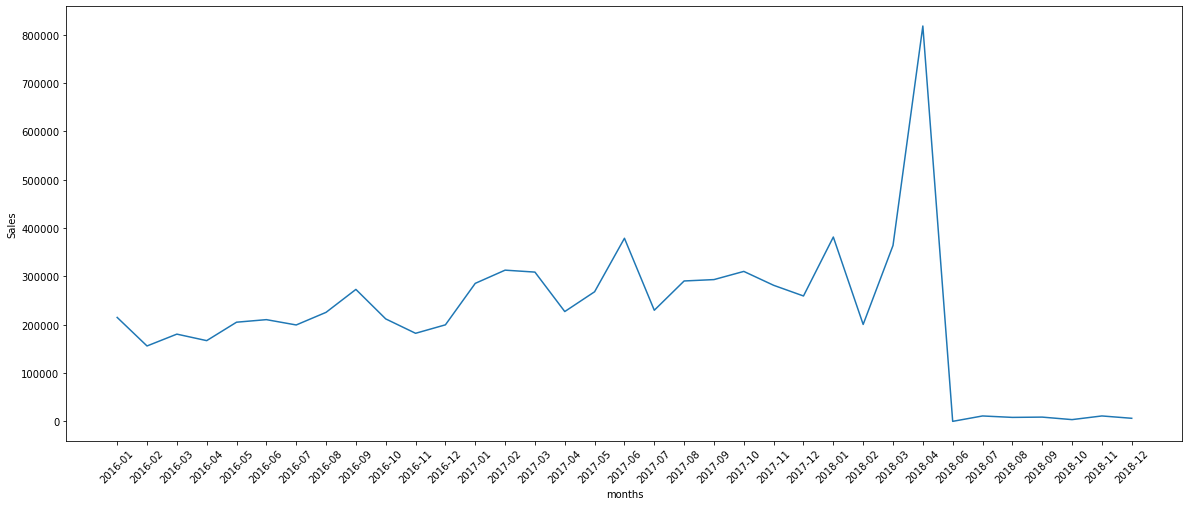

In [27]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(data = seasonality, x = 'months', y = 'Sales', ax = ax)
plt.xticks(rotation = 45)

In [28]:
top_performers = pd.read_sql("""

SELECT 
    oi.product_id,
    p.product_name,
    b.brand_name,
    SUM(oi.list_price * oi.quantity *(1-oi.discount)) AS Sales,
    ROW_NUMBER () OVER(ORDER BY SUM(oi.list_price * oi.quantity *(1-oi.discount)) DESC) AS rank
FROM 
    products as p
        JOIN 
    orders_items as oi 
        ON p.product_id = oi.product_id
        JOIN
    brands as b
        ON b.brand_id = p.brand_id
GROUP BY 1
ORDER BY 5
limit 10;

""", connection)
top_performers

,product_id,product_name,brand_name,Sales,rank
0,7,Trek Slash 8 27.5 - 2016,Trek,555558.6111,1
1,9,Trek Conduit+ - 2016,Trek,389248.7025,2
2,4,Trek Fuel EX 8 29 - 2016,Trek,368472.7294,3
3,11,Surly Straggler 650b - 2016,Surly,226765.5510,4
4,56,Trek Domane SLR 6 Disc - 2017,Trek,211584.6153,5
5,10,Surly Straggler - 2016,Surly,203507.6200,6
6,8,Trek Remedy 29 Carbon Frameset - 2016,Trek,203380.8701,7
7,61,Trek Powerfly 8 FS Plus - 2017,Trek,188249.6235,8
8,58,Trek Madone 9.2 - 2017,Trek,175899.6482,9
9,51,Trek Silque SLR 8 Women's - 2017,Trek,174524.7315,10


In [29]:
# extract the top 10 customer based on total purchase amount.
# inner1 - customer name, total spent
# inner 2 - ranking based on total spent desc
# outer - all col but where rank is less than 11

pd.read_sql("""
SELECT T2.* 
from 
(select t1.*,
       RANK() OVER (ORDER BY total_spent desc) as rnk
FROM 

(SELECT  c.first_name||' '|| c.last_name AS full_name,
       SUM(oi.quantity * oi.list_price *(1-oi.discount)) AS total_spent
       FROM orders_items oi
INNER JOIN orders o
ON oi.order_id=o.order_id
INNER JOIN customers c
ON c.customer_id=o.customer_id
GROUP BY 1) t1) t2
WHERE rnk <11;

""", connection)

,full_name,total_spent,rnk
0,Sharyn Hopkins,34807.9392,1
1,Pamelia Newman,33634.2604,2
2,Abby Gamble,32803.0062,3
3,Lyndsey Bean,32675.0725,4
4,Emmitt Sanchez,31925.8857,5
5,Melanie Hayes,31913.6902,6
6,Debra Burks,27888.1834,7
7,Elinore Aguilar,25636.4531,8
8,Corrina Sawyer,25612.7021,9
9,Shena Carter,24890.6244,10


In [30]:
# extact top 10 customers (here most for the top transaction customer are having total transactions as 3 so we filtered 
# based on that condition) with respect to desc order of total transactions and rank accordingly.

pd.read_sql("""
SELECT c.first_name||' '|| c.last_name AS full_name, count(o.order_id) as total_transactions,
rank() over(order by count(o.order_id) DESC) as rnk
FROM orders o
join customers c
on o.customer_id = c.customer_id
GROUP BY 1 HAVING total_transactions = 3
;
""", connection)

,full_name,total_transactions,rnk
0,Williemae Holloway,3,1
1,Tobie Little,3,1
2,Tameka Fisher,3,1
3,Saturnina Garner,3,1
4,Ronna Butler,3,1
5,Robby Sykes,3,1
6,Pamelia Newman,3,1
7,Mozelle Carter,3,1
8,Monika Berg,3,1
9,Merlene Vinson,3,1


In [31]:
# Analyzed average time intervals between consecutive purchases to understand customer buying patterns and optimize 
# re-engagement tactics.
# inner query to calculate average time between consicutive purchases for customer (lag and lead function, partition by 
# customer id)
# outer query - differene btw avg order date and previous order date based on customer id.
pd.read_sql(""" 

WITH table1 AS(
    SELECT
        o.customer_id,
        o.order_date,
        LAG(o.order_date) OVER (PARTITION BY o.customer_id ORDER BY o.order_date) AS prev_purchase_date
    FROM
        orders o
), table2 AS(
    SELECT
        customer_id,
        julianday(order_date) - julianday(prev_purchase_date) AS interval_days
    FROM
        table1
)
SELECT
    customer_id,
    AVG(interval_days) AS avg_interval_days
FROM
    table2
GROUP BY customer_id
ORDER BY avg_interval_days DESC;

""", connection)

,customer_id,avg_interval_days
0,60,837.0
1,91,832.0
2,175,829.0
3,57,822.0
4,80,821.0
...,...,...
1440,100,NaN
1441,99,NaN
1442,98,NaN
1443,96,NaN


In [32]:
pd.read_sql(""" 
SELECT
    customer_id,
    AVG(julianday(order_date) - julianday(prev_order_date)) AS avg_days_between_purchases
FROM 
    (
     SELECT
         customer_id,
         order_date,
         LAG(order_date) OVER (PARTITION BY customer_id ORDER BY order_date) AS prev_order_date
     FROM
         orders o
    ) subquery
WHERE 
    prev_order_date IS NOT NULL
GROUP BY 1
ORDER BY 2 DESC;
        
""", connection)

,customer_id,avg_days_between_purchases
0,60,837.0
1,91,832.0
2,175,829.0
3,57,822.0
4,80,821.0
...,...,...
126,92,70.0
127,63,66.0
128,109,56.0
129,117,7.0


In [33]:
pd.read_sql("""

SELECT o.store_id, COUNT(DISTINCT oi.order_id) as total_transactions,
SUM(oi.quantity * oi.list_price *(1-oi.discount)) AS total_spent
FROM orders o
JOIN orders_items oi
ON o.order_id = oi.order_id
GROUP BY 1
ORDER BY 2 DESC;

""",connection)

,store_id,total_transactions,total_spent
0,2,1093,5.215751e+06
1,1,348,1.605823e+06
2,3,174,8.675422e+05


In [34]:
pd.read_sql("""

SELECT o.store_id, COUNT(DISTINCT oi.order_id) as total_transactions,
SUM(oi.list_price) AS total_price,
SUM(oi.discount) AS total_discount,
SUM(oi.quantity * oi.list_price *(1-oi.discount)) AS total_spent
FROM orders o
JOIN orders_items oi
ON o.order_id = oi.order_id
GROUP BY 1
ORDER BY 2 DESC;

""",connection)

,store_id,total_transactions,total_price,total_discount,total_spent
0,2,1093,3894954.72,340.36,5.215751e+06
1,1,348,1191373.67,104.86,1.605823e+06
2,3,174,640078.18,52.35,8.675422e+05


In [35]:
# check if all stores have high demanding product category in the store
graph = pd.read_sql("""

SELECT o.store_id, c.category_name, COUNT(DISTINCT oi.order_id) as total_transactions
FROM orders o
JOIN orders_items oi
ON o.order_id = oi.order_id
JOIN products p
ON p.product_id = oi.product_id
JOIN categories c
ON c.category_id = p.category_id
GROUP BY 1,2
ORDER BY 3 DESC,1 DESC
;

""",connection)
graph

,store_id,category_name,total_transactions
0,2,Cruisers Bicycles,648
1,2,Mountain Bikes,581
2,2,Children Bicycles,433
3,2,Comfort Bicycles,320
4,2,Road Bikes,208
5,1,Cruisers Bicycles,199
6,1,Mountain Bikes,194
7,2,Cyclocross Bicycles,171
8,1,Children Bicycles,136
9,2,Electric Bikes,125


<AxesSubplot:xlabel='category_name', ylabel='total_transactions'>

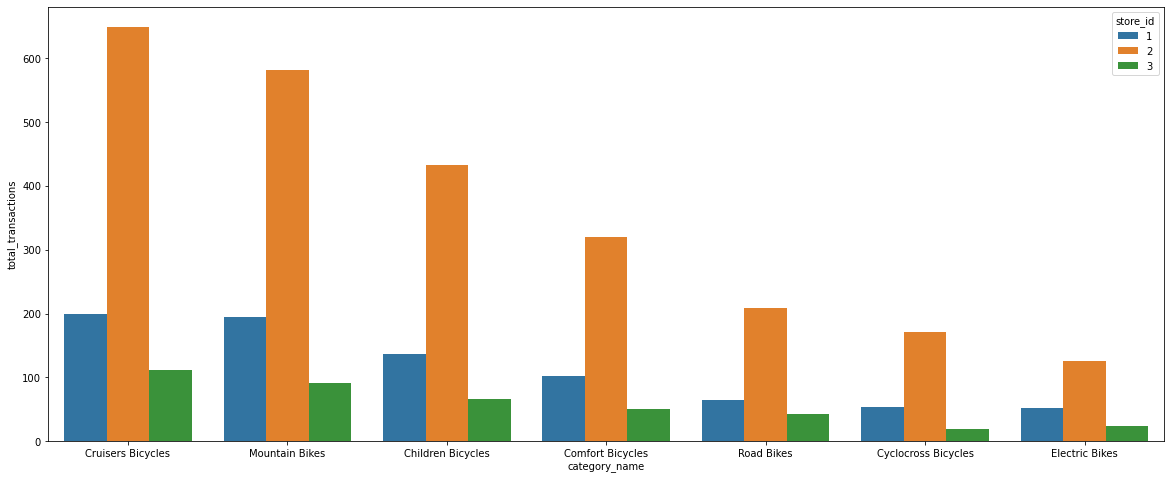

In [36]:
fig, ax = plt.subplots(figsize=(20,8))
sns.barplot(data = graph, x = 'category_name', y = 'total_transactions', hue = 'store_id', ax=ax)

In [37]:
seasonality2 = pd.read_sql("""

With table1 as(
SELECT *
FROM products as p
JOIN categories as c
ON p.category_id  = c.category_id
),
table2 as(
SELECT oi.product_id,
strftime('%m', o.order_date) as month,
strftime('%Y', o.order_date) as year,
SUM(oi.quantity) as total_units,
SUM(oi.quantity * oi.list_price *(1-oi.discount)) AS total_spent
FROM orders as o
        JOIN 
    orders_items as oi 
        ON o.order_id = oi.order_id
GROUP BY 1,2,3
)

SELECT t1.category_name, t2.month, avg(t2.total_spent) as avg_total_spent
FROM table1 as t1
JOIN table2 as t2
ON t1.product_id = t2.product_id
GROUP BY 1,2;

""", connection)
seasonality2

,category_name,month,avg_total_spent
0,Children Bicycles,01,727.470911
1,Children Bicycles,02,765.154663
2,Children Bicycles,03,725.255718
3,Children Bicycles,04,733.134187
4,Children Bicycles,05,759.462820
...,...,...,...
79,Road Bikes,08,7890.731544
80,Road Bikes,09,10006.411982
81,Road Bikes,10,6595.296960
82,Road Bikes,11,7088.971723


<AxesSubplot:xlabel='month', ylabel='avg_total_spent'>

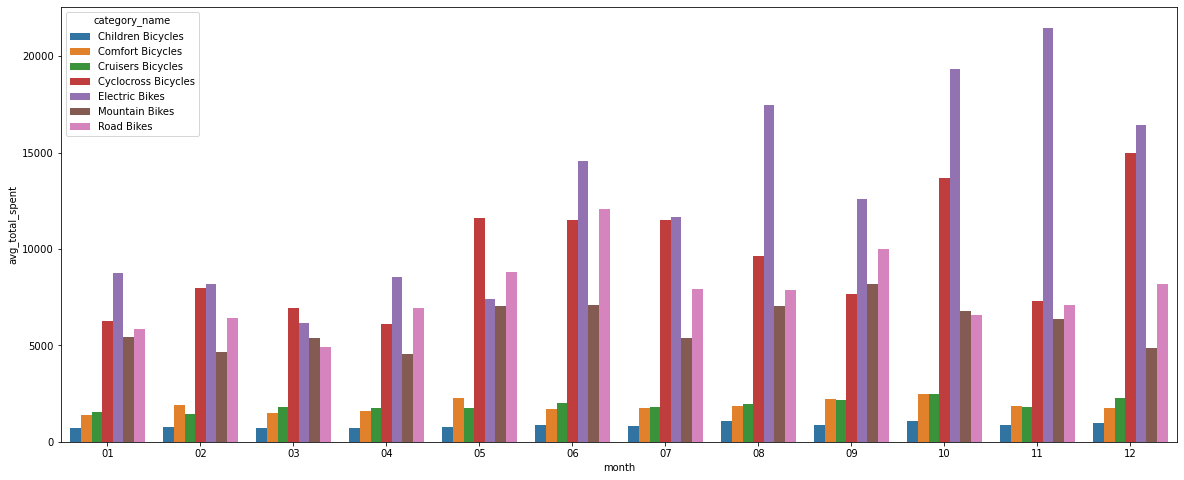

In [38]:
fig, ax = plt.subplots(figsize=(20,8))
sns.barplot(data = seasonality2, x = 'month', y = 'avg_total_spent', hue = 'category_name', ax=ax)

In [39]:
# Market basket analysis:

# Market basket analysis is used to discover similar patterns and interrelationships b/w items in large data sets. It is 
# useful to analyse cutomer purchase behaviour and identify freqentily occuring items in developing strategical insights.

# support - frequency or proportion of transaction that contain a particular item set. Many people buy in higher quantities it
# is for understanding product market fit and customer purchase behaviour and sentiment analysis.

# confidence - a measure of how often item in a rule appear together. It is a conditional probability of a consequent given the 
# antecedent. likeliness of one product being a part of combination of the majority items.

In [40]:
data = {'Transaction': [1, 2, 3, 4, 5],
        'Items': [['Milk', 'Bread'],
                  ['Bread', 'Butter'],
                  ['Milk', 'Bread', 'Butter'],
                  ['Milk'],
                  ['Bread', 'Butter']]}
df = pd.DataFrame(data)
df

,Transaction,Items
0,1,"[Milk, Bread]"
1,2,"[Bread, Butter]"
2,3,"[Milk, Bread, Butter]"
3,4,[Milk]
4,5,"[Bread, Butter]"


In [41]:
# concordant products - if milk purchase is inc. and butter purchase is also inc.
# Discordant products - if milk purchase is inc. and butter purchase is also dec.

In [42]:
# !pip install mlxtend

In [43]:
# Apriori algorithm for market basket analysis
from mlxtend.frequent_patterns import apriori, association_rules

In [44]:
all_items = sorted(set(item for sublist in df['Items'] for item in sublist))
all_items

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


['Bread', 'Butter', 'Milk']

In [45]:
# applying onehot encoding
encoded_data = []
for index, row in df.iterrows():
    encoded_row = {item: (item in row['Items']) for item in all_items}
    encoded_data.append(encoded_row)
    
encoded_data

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


[{'Bread': True, 'Butter': False, 'Milk': True},
 {'Bread': True, 'Butter': True, 'Milk': False},
 {'Bread': True, 'Butter': True, 'Milk': True},
 {'Bread': False, 'Butter': False, 'Milk': True},
 {'Bread': True, 'Butter': True, 'Milk': False}]

In [46]:
df_encoded = pd.DataFrame(encoded_data)
df_encoded

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Bread,Butter,Milk
0,True,False,True
1,True,True,False
2,True,True,True
3,False,False,True
4,True,True,False


In [47]:
frequent_itemsets = apriori(df_encoded, min_support=0.3, use_colnames=True)
frequent_itemsets

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets
0,0.8,(Bread)
1,0.6,(Butter)
2,0.6,(Milk)
3,0.6,"(Butter, Bread)"
4,0.4,"(Milk, Bread)"


In [48]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
rules

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Butter),(Bread),0.6,0.8,0.6,1.00,1.25,0.12,inf,0.5
1,(Bread),(Butter),0.8,0.6,0.6,0.75,1.25,0.12,1.6,1.0


1) itenfication of frequent item set - item set considered frequent if it appears in a sufficiet number of transactions.

2) association_rule -  it has an anticedent (if part of a condition) and a consequent (then part of condition). For ex. 
a rule could be milk - bread with a confidence of 0.8 this means 80% of the transactions containing milk also contain bread

3) lift - ratio of observed support to that of expected if the anticedent and consequent were independent.

4) Leverage: It measures the difference the observed frequency of an item set and the freuency that would be expected if 
the items were independent. Leverage(A⇒B)=P(A∩B)−P(A)P(B)
Leverage rate can range from -1 to 1. A value of 0 indicates no association between the items (independent events).
Positive value indicates a positive association (items occuring together more than than expected)
Negative value indicates a negative association (items occuring together less than than expected)

Leverage measures the difference between the observed frequency of co-occurrence of two items in a dataset and the 
frequency that would be expected if the items were independent.

Example: Let's say we have a dataset of grocery purchases, and we want to analyze the leverage between items "milk" and 
"bread". If the leverage is positive, it means that customers tend to buy milk and bread together more often than if they 
were bought independently.

5) conviction - Conviction measures the ratio of the expected support for the consequent under independence to its 
observed support.
Value of 1: Indicates that the antecedent (A) and consequent (B) are independent.
Higher Values: Indicate stronger associations between A and B.
Conviction of 2: Means that the rule is twice as likely to make an incorrect prediction compared to an independent scenario.

Example: Suppose we have a rule that states "if a customer buys milk (A), they are likely to buy bread (B)". If the 
conviction value is high (e.g., 3), it indicates a strong association where the rule is significantly more likely to be 
true then false.

6) zhangs_metric - Zhang's metric is a measure used in association rule mining that combines elements of leverage and 
conviction to evaluate the strength of association rules.
Zhang's metric provides a combined measure of the deviation from independence (leverage) relative to the strength of 
association (confidence).

Continuing with our grocery example, let's say we calculate Zhang's metric for the association rule 
"milk (A) ⇒ bread (B)". If Zhang's metric is positive and high, it indicates that milk and bread are associated more 
strongly than would be expected by chance, considering both the deviation from independence (leverage) and the strength of 
the association (confidence).


Leverage: Measures the deviation of the observed co-occurrence of items from the expected co-occurrence under independence.
Conviction: Measures the likelihood that the association rule makes an incorrect prediction.
Zhang's Metric: Combines leverage and confidence to provide a comprehensive measure of association strength in association 
rule mining.

In [49]:
# Executed market basket analysis to uncover frequently co-purchased products, aiding in cross-selling and upselling 
# strategies.
# Extract the query to find frequently co-purchased products with the specific products. 
# lint - perfrm an innerjoin in a inner query with self join b/w order items and order items and products with products to 
# extract product name from first products table as product A and second product name as poduct B, count(*) as co-purchase
# outer query - extract the prepared columns by ordering with respect to co-puchased count in DESC.

pd.read_sql("""
WITH table1 AS (
    SELECT o1.order_id, o1.product_id
    FROM orders_items o1
    INNER JOIN orders_items o2 ON o1.order_id = o2.order_id  AND o1.product_id <> o2.product_id
    WHERE o1.product_id != o2.product_id
),
table2 AS (
    SELECT p1.product_id
    FROM products p1
    INNER JOIN products p2 ON p1.product_id = p2.product_id
)

SELECT t1.product_id, COUNT(t1.order_id) AS co_purchase
FROM table1 t1
INNER JOIN table2 t2 ON t1.product_id = t2.product_id
GROUP BY t1.product_id
ORDER BY co_purchase DESC;
""", connection)

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,product_id,co_purchase
0,6,264
1,7,254
2,12,250
3,23,248
4,13,244
...,...,...
299,280,1
300,270,1
301,256,1
302,176,1


In [50]:
basket = pd.read_sql(""" 
SELECT
    product_a,
    product_b,
    co_purchase_count
FROM 
    (
     SELECT
         p1.product_name AS product_a,
         p2.product_name AS product_b,
         COUNT(*) AS co_purchase_count
     FROM
         orders_items s1
     INNER JOIN
         orders_items s2 ON s1.order_id = s2.order_id AND s1.product_id <> s2.product_id
     INNER JOIN
         products p1 ON s1.product_id = p1.product_id
     INNER JOIN
         products p2 ON s2.product_id = p2.product_id
     GROUP BY
         p1.product_id, p2.product_id
    ) subquery
ORDER BY
    co_purchase_count DESC;
    
""", connection)
basket

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,product_a,product_b,co_purchase_count
0,Heller Shagamaw Frame - 2016,Electra Girl's Hawaii 1 (16-inch) - 2015/2016,15
1,Electra Girl's Hawaii 1 (16-inch) - 2015/2016,Heller Shagamaw Frame - 2016,15
2,Trek Conduit+ - 2016,Surly Straggler 650b - 2016,14
3,Surly Straggler 650b - 2016,Trek Conduit+ - 2016,14
4,Electra Townie Original 21D - 2016,Electra Cruiser 1 (24-Inch) - 2016,14
...,...,...,...
6923,Electra Townie Original 21D EQ Ladies' - 2018,Trek X-Caliber Frameset - 2018,1
6924,Electra Townie Original 21D Ladies' - 2018,Trek Girl's Kickster - 2017,1
6925,Electra Townie Original 21D Ladies' - 2018,Trek Domane SL 8 Disc - 2018,1
6926,Electra Townie Original 21D Ladies' - 2018,Trek Conduit+ - 2018,1


In [51]:
# Apriori algorithm for market basket analysis
from mlxtend.frequent_patterns import apriori, association_rules

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [59]:
all_products = sorted(set(basket['product_a']).union(set(basket['product_b'])))
all_products

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


["Electra Amsterdam Fashion 3i Ladies' - 2017/2018",
 "Electra Amsterdam Fashion 7i Ladies' - 2017",
 'Electra Amsterdam Original 3i - 2015/2017',
 "Electra Amsterdam Original 3i Ladies' - 2017",
 'Electra Amsterdam Royal 8i Ladies - 2018',
 'Electra Cruiser 1 (24-Inch) - 2016',
 'Electra Cruiser 1 - 2016/2017/2018',
 "Electra Cruiser 1 Ladies' - 2018",
 'Electra Cruiser 1 Tall - 2016/2018',
 "Electra Cruiser 7D (24-Inch) Ladies' - 2016/2018",
 'Electra Cruiser 7D - 2016/2017/2018',
 "Electra Cruiser 7D Ladies' - 2016/2018",
 'Electra Cruiser 7D Tall - 2016/2018',
 'Electra Cruiser Lux 1 - 2016/2018',
 'Electra Cruiser Lux 1 - 2017',
 "Electra Cruiser Lux 1 Ladies' - 2018",
 'Electra Cruiser Lux 3i - 2018',
 "Electra Cruiser Lux 3i Ladies' - 2018",
 'Electra Cruiser Lux 7D - 2018',
 "Electra Cruiser Lux 7D Ladies' - 2018",
 'Electra Cruiser Lux Fat Tire 1 Ladies - 2017',
 'Electra Cruiser Lux Fat Tire 7D - 2018',
 "Electra Cyclosaurus 1 (16-inch) - Boy's - 2018",
 "Electra Daydreamer 3

In [61]:
transactions = {product: [] for product in all_products}
transactions

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


{"Electra Amsterdam Fashion 3i Ladies' - 2017/2018": [],
 "Electra Amsterdam Fashion 7i Ladies' - 2017": [],
 'Electra Amsterdam Original 3i - 2015/2017': [],
 "Electra Amsterdam Original 3i Ladies' - 2017": [],
 'Electra Amsterdam Royal 8i Ladies - 2018': [],
 'Electra Cruiser 1 (24-Inch) - 2016': [],
 'Electra Cruiser 1 - 2016/2017/2018': [],
 "Electra Cruiser 1 Ladies' - 2018": [],
 'Electra Cruiser 1 Tall - 2016/2018': [],
 "Electra Cruiser 7D (24-Inch) Ladies' - 2016/2018": [],
 'Electra Cruiser 7D - 2016/2017/2018': [],
 "Electra Cruiser 7D Ladies' - 2016/2018": [],
 'Electra Cruiser 7D Tall - 2016/2018': [],
 'Electra Cruiser Lux 1 - 2016/2018': [],
 'Electra Cruiser Lux 1 - 2017': [],
 "Electra Cruiser Lux 1 Ladies' - 2018": [],
 'Electra Cruiser Lux 3i - 2018': [],
 "Electra Cruiser Lux 3i Ladies' - 2018": [],
 'Electra Cruiser Lux 7D - 2018': [],
 "Electra Cruiser Lux 7D Ladies' - 2018": [],
 'Electra Cruiser Lux Fat Tire 1 Ladies - 2017': [],
 'Electra Cruiser Lux Fat Tire 7

In [62]:
for _, row in basket.iterrows():
    transactions[row['product_a']].append(row['product_b'])
    transactions[row['product_b']].append(row['product_a'])

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [63]:
encoded_data = []
for product in all_products:
    encoded_row = {item: (item in transactions[product]) for item in all_products}
    encoded_data.append(encoded_row)

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [64]:
df_encoded_bskt = pd.DataFrame(encoded_data, index=all_products)

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [65]:
frequent_itemsets = apriori(df_encoded_bskt, min_support=0.1, use_colnames=True)
print(frequent_itemsets)

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


       support                                           itemsets
0     0.188406      (Electra Amsterdam Fashion 7i Ladies' - 2017)
1     0.144928        (Electra Amsterdam Original 3i - 2015/2017)
2     0.173913     (Electra Amsterdam Original 3i Ladies' - 2017)
3     0.304348               (Electra Cruiser 1 (24-Inch) - 2016)
4     0.123188                     (Electra Cruiser Lux 1 - 2017)
...        ...                                                ...
2940  0.101449  (Surly Ice Cream Truck Frameset - 2016, Electr...
2941  0.101449  (Electra Cruiser 1 (24-Inch) - 2016, Electra G...
2942  0.108696  (Surly Ice Cream Truck Frameset - 2016, Electr...
2943  0.101449  (Electra Townie Original 21D - 2016, Surly Ice...
2944  0.101449  (Electra Townie Original 21D - 2016, Surly Ice...

[2945 rows x 2 columns]


In [66]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules

G:\ANACONDA\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Electra Amsterdam Fashion 7i Ladies' - 2017),(Electra Cruiser 1 (24-Inch) - 2016),0.188406,0.304348,0.134058,0.711538,2.337912,0.076717,2.411594,0.705116
1,(Electra Amsterdam Fashion 7i Ladies' - 2017),(Electra Girl's Hawaii 1 (16-inch) - 2015/2016),0.188406,0.289855,0.130435,0.692308,2.388462,0.075824,2.307971,0.716270
2,(Electra Amsterdam Fashion 7i Ladies' - 2017),"(Electra Girl's Hawaii 1 16"" - 2017)",0.188406,0.289855,0.115942,0.615385,2.123077,0.061332,1.846377,0.651786
3,(Electra Amsterdam Fashion 7i Ladies' - 2017),(Electra Townie Original 21D - 2016),0.188406,0.326087,0.119565,0.634615,1.946154,0.058129,1.844394,0.599026
4,(Electra Amsterdam Fashion 7i Ladies' - 2017),(Electra Townie Original 7D - 2017),0.188406,0.264493,0.105072,0.557692,2.108535,0.055240,1.662886,0.647783
...,...,...,...,...,...,...,...,...,...,...
18551,(Electra Townie Original 7D EQ - Women's - 201...,"(Heller Shagamaw Frame - 2016, Electra Townie ...",0.173913,0.119565,0.101449,0.583333,4.878788,0.080655,2.113043,0.962406
18552,"(Heller Shagamaw Frame - 2016, Electra Girl's ...",(Electra Townie Original 7D EQ - Women's - 201...,0.170290,0.115942,0.101449,0.595745,5.138298,0.081706,2.186880,0.970680
18553,(Electra Townie Original 7D EQ - Women's - 201...,"(Heller Shagamaw Frame - 2016, Electra Townie ...",0.166667,0.134058,0.101449,0.608696,4.540541,0.079106,2.212963,0.935714
18554,"(Heller Shagamaw Frame - 2016, Electra Townie ...",(Electra Townie Original 7D EQ - Women's - 201...,0.173913,0.130435,0.101449,0.583333,4.472222,0.078765,2.086957,0.939850
